# Dynamic spectrum FITS — Stokes I and V / I

Uses `lwasolarutl.spec` and `lwasolarutl.visualization.plot_spec` ([lwasolarview](https://github.com/peijin94/lwasolarview/blob/main/plot_spec_fits.py)).

Demo file: `../demofile/20260513.fits`

```bash
pip install git+https://github.com/ovro-eovsa/lwa-solar-util.git
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import lwasolarutl as lsu

REPO = Path("..").resolve() if (Path("..") / "demofile").exists() else Path(".").resolve()
SPEC_FITS = REPO / "demofile" / "20260513.fits"

print("Spectrum FITS:", SPEC_FITS)
print("Exists:", SPEC_FITS.exists())

Spectrum FITS: /fast/peijinz/lwa-solar-util/demofile/20260513.fits
Exists: True


## Load spectrum

In [2]:
spec = lsu.spec.load_spectrum_fits(str(SPEC_FITS))
print("I shape:", spec.spec_I.shape, "V shape:", spec.spec_V.shape)
print("nfreq:", len(spec.freqs_mhz), "MHz range:", spec.freqs_mhz[0], "…", spec.freqs_mhz[-1])
print("ntime:", len(spec.times), "from", spec.times[0].iso, "to", spec.times[-1].iso)

I shape: (731, 167448) V shape: (731, 167448)
nfreq: 731 MHz range: 15.03735315054655 … 84.9006325006485
ntime: 167448 from 2026-05-13 13:45:00.135 to 2026-05-14 01:54:59.775


## Plot (two panels: Stokes I, V/I)

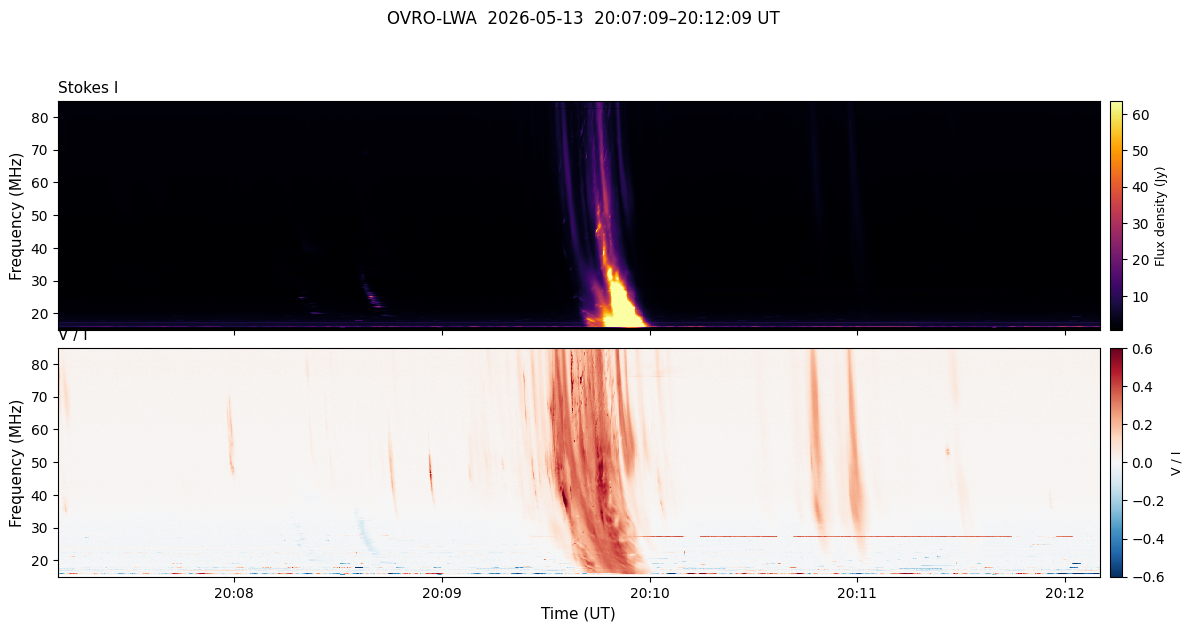

In [3]:
fig, axes = lsu.visualization.plot_spec(
    spec,
    pct_hi_I=99.6,
    t_range_ratio=(0.523, 0.53),
    vi_range=(-0.6, 0.6),)
plt.show()

## Optional: save PNG

In [4]:
out = REPO / "demofile" / "20260513_spec_demo.png"
fig2, _ = lsu.visualization.plot_spec(str(SPEC_FITS), outpath=str(out))
plt.close(fig2)
print("Saved:", out, out.exists())

Saved: /fast/peijinz/lwa-solar-util/demofile/20260513_spec_demo.png True
